In [70]:
# Import Library
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

In [71]:
# Load Dataset
data = pd.read_excel("Dataset_Kualitas_Air_1000.xlsx")
data.columns = data.columns.str.strip()

print(data.head())

     Tanggal  Temperatur    pH    DO   BOD   COD  TSS   TDS
0 2014-03-09        26.0  7.07  5.37  2.14  15.9   32   480
1 2014-03-09        25.9  6.99  5.44  2.14  16.0   32   480
2 2014-03-09        25.8  6.92  5.54  2.14  16.0   32   480
3 2014-03-09        25.7  6.69  5.60  2.18  16.0   32   480
4 2014-03-09        26.5  6.36  3.90  3.10  26.0   52  1001


In [72]:
data_mentah = data.copy()

In [73]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     1000 non-null   datetime64[ns]
 1   Temperatur  1000 non-null   float64       
 2   pH          1000 non-null   float64       
 3   DO          1000 non-null   float64       
 4   BOD         1000 non-null   float64       
 5   COD         1000 non-null   float64       
 6   TSS         1000 non-null   int64         
 7   TDS         1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 62.6 KB


,Tanggal,Temperatur,pH,DO,BOD,COD,TSS,TDS
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2020-01-22 00:31:40.800000256,28.448500,5.924750,3.636240,4.126690,29.540800,61.794000,1092.252000
min,2014-03-09 00:00:00,25.700000,5.000000,2.000000,1.330000,15.900000,32.000000,480.000000
25%,2017-03-04 00:00:00,27.500000,5.000000,2.730000,2.990000,25.000000,50.000000,1000.000000
50%,2020-03-02 00:00:00,27.800000,6.250000,3.900000,3.450000,26.900000,55.000000,1040.000000
75%,2023-03-04 00:00:00,29.300000,6.420000,4.400000,5.635000,33.300000,70.000000,1160.000000
max,2025-08-18 00:00:00,31.500000,7.720000,5.600000,6.500000,45.000000,120.000000,1600.000000
std,NaN,1.422597,0.679444,0.995495,1.486878,6.245881,16.946703,140.063236


In [74]:
# Preprocessing
fitur = ["Temperatur", "pH", "DO", "BOD", "COD", "TSS", "TDS"]

data[fitur] = data[fitur].apply(pd.to_numeric, errors="coerce")

imputer = SimpleImputer(strategy="mean")
data[fitur] = imputer.fit_transform(data[fitur])

print("Missing value setelah imputasi:")
print(data[fitur].isnull().sum())

Missing value setelah imputasi:
Temperatur    0
pH            0
DO            0
BOD           0
COD           0
TSS           0
TDS           0
dtype: int64


In [75]:
# =====================================================
# PENANGANAN DUPLIKASI
# =====================================================
print("=== 1. PENANGANAN DUPLIKASI ===")
dup_before = data.duplicated().sum()
print(f"Jumlah data duplikat sebelum: {dup_before}")

# Proses Hapus Duplikat
data = data.drop_duplicates().reset_index(drop=True)

dup_after = data.duplicated().sum()
print(f"Jumlah data duplikat sesudah: {dup_after}")
print(f"Total baris data sekarang: {len(data)}")
print("-" * 30)

=== 1. PENANGANAN DUPLIKASI ===
Jumlah data duplikat sebelum: 69
Jumlah data duplikat sesudah: 0
Total baris data sekarang: 931
------------------------------


In [76]:
# =====================================================
# PENANGANAN OUTLIER (IQR Capping)
# =====================================================
print("=== 2. PENANGANAN OUTLIER ===")

# Tampilan sebelum (statistik deskriptif)
print("Statistik (Max) sebelum handling outlier:")
print(data[fitur].max())

# Proses Capping Outlier
for col in fitur:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: Nilai di atas upper diubah jadi upper, di bawah lower jadi lower
    data[col] = np.clip(data[col], lower_bound, upper_bound)

print("\nStatistik (Max) sesudah handling outlier:")
print(data[fitur].max())
print("-" * 30)

=== 2. PENANGANAN OUTLIER ===
Statistik (Max) sebelum handling outlier:
Temperatur      31.50
pH               7.72
DO               5.60
BOD              6.50
COD             45.00
TSS            120.00
TDS           1600.00
dtype: float64

Statistik (Max) sesudah handling outlier:
Temperatur      31.50
pH               7.72
DO               5.60
BOD              6.50
COD             45.00
TSS            100.00
TDS           1400.00
dtype: float64
------------------------------


In [77]:
# =====================================================================
# PENENTUAN LABEL KUALITAS AIR BERDASARKAN KEPMEN LH 115/2003 & PP 22/2021
# =====================================================================

# BAKU MUTU PP 22/2021 KELAS II
BM = {
    "pH_min": 6,
    "pH_max": 9,
    "DO": 4,        # Batas minimum oksigen terlarut
    "BOD": 3,
    "COD": 25,
    "TSS": 50,
    "TDS": 1000,
    "Temperatur": 3
}

# Konstanta Pendukung Perhitungan IP
TEMP_ALAMI = 28
C_MAKS_DO = 7.5  # Batas saturasi oksigen jenuh teoretis air murni pada kondisi tropis Pontianak

# =====================================================================
# FUNGSI HITUNG IP (TERKOREKSI TOTAL KEPMEN LH 115/2003)
# =====================================================================
def hitung_ip(row):
    rasio_baru = []

    # 1. PARAMETER pH (Metode Rentang Khusus)
    L_min = BM["pH_min"]
    L_max = BM["pH_max"]
    L_mid = (L_min + L_max) / 2

    if row["pH"] < L_mid:
        r_ph = (L_mid - row["pH"]) / (L_mid - L_min)
    else:
        r_ph = (row["pH"] - L_mid) / (L_max - L_mid)
    
    # Pengerem Logaritma jika Rasio pH > 1.0
    if r_ph > 1.0:
        r_ph = 1.0 + 5 * np.log10(r_ph)
    rasio_baru.append(r_ph)


    # 2. PARAMETER DO (Menggunakan Rumus Khusus Parameter Terbalik)
    # Rumus: (C_maks - C_i) / (C_maks - L_ij)
    r_do = (C_MAKS_DO - row["DO"]) / (C_MAKS_DO - BM["DO"])
    
    # Pengerem Logaritma jika Rasio DO > 1.0
    if r_do > 1.0:
        r_do = 1.0 + 5 * np.log10(r_do)
    rasio_baru.append(r_do)


    # 3. PARAMETER AKUMULATIF LINEAR (BOD, COD, TSS, TDS)
    for p in ["BOD", "COD", "TSS", "TDS"]:
        r_linear = row[p] / BM[p]
        
        # Pengerem Logaritma jika Rasio Akumulatif > 1.0
        if r_linear > 1.0:
            r_linear = 1.0 + 5 * np.log10(r_linear)
        rasio_baru.append(r_linear)


    # 4. PARAMETER TEMPERATUR (Deviasi Absolut terhadap Suhu Alami)
    dev_temp = abs(row["Temperatur"] - TEMP_ALAMI)
    r_temp = dev_temp / BM["Temperatur"]
    
    # Pengerem Logaritma jika Rasio Temperatur > 1.0
    if r_temp > 1.0:
        r_temp = 1.0 + 5 * np.log10(r_temp)
    rasio_baru.append(r_temp)


    # =================================================================
    # AGREGASI NILAI INDEKS PENCEMARAN (IP)
    # =================================================================
    R = np.mean(rasio_baru)  # Nilai rata-rata rasio baru keseluruhan
    M = np.max(rasio_baru)   # Nilai maksimum rasio baru keseluruhan

    return np.sqrt((M**2 + R**2) / 2)

In [78]:
data["IP"] = data.apply(hitung_ip, axis=1)

print("Kolom IP berhasil dibuat")
print(data[["IP"]].head())

def label_ip_binary(ip):
    return 0 if ip <= 1 else 1

data["Label_IP"] = data["IP"].apply(label_ip_binary)

print(data["Label_IP"].value_counts())

Kolom IP berhasil dibuat
         IP
0  0.691709
1  0.696225
2  0.699540
3  0.715073
4  1.014182
Label_IP
1    513
0    418
Name: count, dtype: int64


In [79]:
# Time Shift (Target = Kondisi Berikutnya)
# Geser label untuk target waktu berikutnya (t+1)
data["Target"] = data["Label_IP"].shift(-1)

# Buang baris terakhir yang target-nya NaN
data = data.dropna().reset_index(drop=True)

# Tampilkan SEMUA FITUR + Label + Target
kolom_time_aware = fitur + ["Label_IP", "Target"]
data[kolom_time_aware].head(10)

,Temperatur,pH,DO,BOD,COD,TSS,TDS,Label_IP,Target
0,26.0,7.07,5.37,2.14,15.9,32.0,760.0,0,0.0
1,25.9,6.99,5.44,2.14,16.0,32.0,760.0,0,0.0
2,25.8,6.92,5.54,2.14,16.0,32.0,760.0,0,0.0
3,25.7,6.69,5.60,2.18,16.0,32.0,760.0,0,1.0
4,26.5,6.36,3.90,3.10,26.0,52.0,1001.0,1,1.0
5,27.0,5.94,3.48,3.82,28.0,57.0,1041.0,1,1.0
6,27.5,5.32,3.12,4.47,30.1,62.0,1081.0,1,1.0
7,28.1,5.00,2.81,5.08,32.2,67.0,1121.0,1,1.0
8,28.7,5.00,2.50,5.92,34.3,72.0,1161.0,1,1.0
9,29.2,5.00,2.00,6.50,36.5,77.0,1202.0,1,1.0


In [80]:
# =====================================================
# STANDARISASI (StandardScaler)
# =====================================================
from sklearn.preprocessing import StandardScaler
import os

print("=== 3. STANDARISASI DATA ===")
print("Sampel data sebelum standarisasi (5 baris):")
print(data[fitur].head())

# Inisialisasi Scaler (Ganti ke StandardScaler)
scaler = StandardScaler()

# Proses Fit & Transform
data[fitur] = scaler.fit_transform(data[fitur])

# Tentukan Folder Output
OUTPUT_DIR = "HASIL_PERCOBAAN_XGBOOST"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# SIMPAN SCALER UNTUK STREAMLIT
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_kualitas_air.pkl")

print("\nSampel data sesudah standarisasi (5 baris):")
print(data[fitur].head())
print("✅ Scaler berhasil disimpan sebagai 'scaler_kualitas_air.pkl'")
print("-" * 30)

=== 3. STANDARISASI DATA ===
Sampel data sebelum standarisasi (5 baris):
   Temperatur    pH    DO   BOD   COD   TSS     TDS
0        26.0  7.07  5.37  2.14  15.9  32.0   760.0
1        25.9  6.99  5.44  2.14  16.0  32.0   760.0
2        25.8  6.92  5.54  2.14  16.0  32.0   760.0
3        25.7  6.69  5.60  2.18  16.0  32.0   760.0
4        26.5  6.36  3.90  3.10  26.0  52.0  1001.0

Sampel data sesudah standarisasi (5 baris):
   Temperatur        pH        DO       BOD       COD       TSS       TDS
0   -1.745077  1.697744  1.768266 -1.361930 -2.233749 -1.967826 -2.770919
1   -1.815529  1.581259  1.838373 -1.361930 -2.217524 -1.967826 -2.770919
2   -1.885980  1.479336  1.938527 -1.361930 -2.217524 -1.967826 -2.770919
3   -1.956432  1.144443  1.998620 -1.335145 -2.217524 -1.967826 -2.770919
4   -1.392820  0.663945  0.296003 -0.719087 -0.595060 -0.634290 -0.752209
✅ Scaler berhasil disimpan sebagai 'scaler_kualitas_air.pkl'
------------------------------


In [81]:
# Split Data Latih & Uji
X = data[fitur]
y = data["Target"]

split_idx = int(0.9 * len(data))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(X_train.shape, X_test.shape)

(837, 7) (93, 7)


In [82]:
X_train_master = X.iloc[:split_idx].copy()
y_train_master = y.iloc[:split_idx].copy()

In [83]:
# =====================================================================
# STRATEGI VALIDASI MENGGUNAKAN 10-FOLD CROSS-VALIDATION (TERPISAH)
# =====================================================================
from sklearn.model_selection import KFold, cross_val_score

print("=== STRATEGI VALIDASI: 10-FOLD CROSS-VALIDATION ===")

# Inisialisasi model dummy khusus simulasi CV agar tidak menimpa model utama
model_cv_dummy = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=3,
    learning_rate=0.01,
    n_estimators=100,
    subsample=0.6,
    colsample_bytree=0.8,
    gamma=0,              
    min_child_weight=1,  
    random_state=42
) 

# Definisikan K-Fold (10 bagian, data diacak agar adil)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Jalankan Cross-Validation secara otomatis untuk metrik AKURASI terhadap seluruh data latih
skor_akurasi = cross_val_score(model_cv_dummy, X_train, y_train, cv=kf, scoring='accuracy')

# Tampilkan hasil evaluasi 10-Fold
print("Akurasi di setiap Fold (1 s/d 10):")
for i, acc in enumerate(skor_akurasi):
    print(f" Fold {i+1}: {acc * 100:.2f}%")

print("\n=== RINGKASAN STABILITAS MODEL ===")
print(f"Rata-rata Akurasi (Mean Accuracy)   : {np.mean(skor_akurasi) * 100:.2f}%")
print(f"Standar Deviasi (Standard Deviation): {np.std(skor_akurasi):.4f}")
print("-" * 50)

=== STRATEGI VALIDASI: 10-FOLD CROSS-VALIDATION ===
Akurasi di setiap Fold (1 s/d 10):
 Fold 1: 69.05%
 Fold 2: 77.38%
 Fold 3: 77.38%
 Fold 4: 82.14%
 Fold 5: 86.90%
 Fold 6: 76.19%
 Fold 7: 83.33%
 Fold 8: 83.13%
 Fold 9: 73.49%
 Fold 10: 81.93%

=== RINGKASAN STABILITAS MODEL ===
Rata-rata Akurasi (Mean Accuracy)   : 79.09%
Standar Deviasi (Standard Deviation): 0.0509
--------------------------------------------------


In [ ]:
# Training Model
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=3,
    learning_rate=0.01,
    n_estimators=100,
    subsample=0.6,
    colsample_bytree=0.8,
    gamma=0,              
    min_child_weight=1,  
    random_state=42
)  # Kombinasi Terbaik: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.6}

model.fit(X_train, y_train)
print("Model selesai dilatih")

Model selesai dilatih


In [85]:
# SIMPAN MODEL FINAL UTAMA
model_final = model

# SIMPAN DATA TEST FINAL
X_test_final = X_test.copy()
y_test_final = y_test.copy()

In [86]:
# Evaluasi Model
y_pred = model.predict(X_test)
print("Akurasi:", round(accuracy_score(y_test, y_pred), 2))
print(classification_report(
    y_test, y_pred,
    target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
))

Akurasi: 0.81
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.81      0.81      0.81        47
    Tidak Memenuhi       0.80      0.80      0.80        46

          accuracy                           0.81        93
         macro avg       0.81      0.81      0.81        93
      weighted avg       0.81      0.81      0.81        93



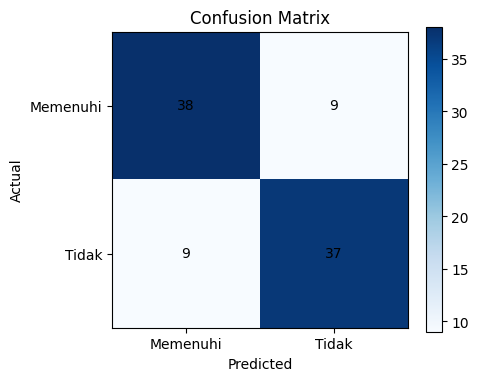

In [87]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Memenuhi", "Tidak"])
plt.yticks([0,1], ["Memenuhi", "Tidak"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

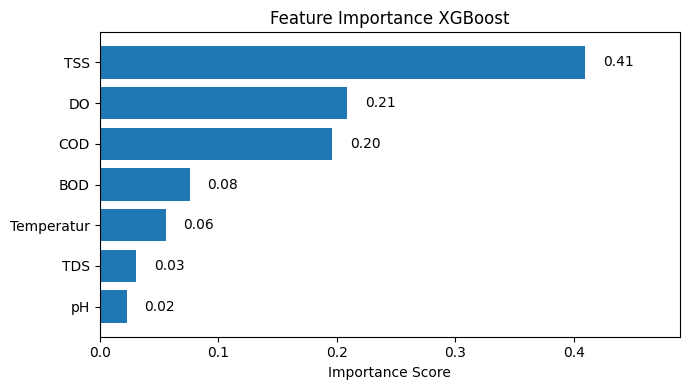

In [88]:
# Feature Importance
importances = model_final.feature_importances_

feature_names = np.array(fitur)

idx = np.argsort(importances)

plt.figure(figsize=(7,4))
bars = plt.barh(feature_names[idx], importances[idx])

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.015, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center')

plt.xlim(0, max(importances) + 0.08)
plt.xlabel("Importance Score")
plt.title("Feature Importance XGBoost")
plt.tight_layout()
plt.show()

Nilai AUC: 0.8189


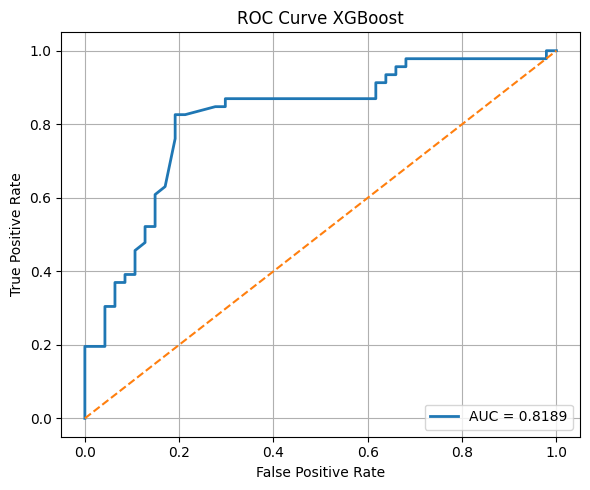

In [89]:
# =========================================
# ROC CURVE & AUC
# =========================================

# Probabilitas prediksi
y_prob = model.predict_proba(X_test)[:, 1]

# Hitung ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Hitung AUC
roc_auc = auc(fpr, tpr)

print("Nilai AUC:", round(roc_auc, 4))

# Plot ROC Curve
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

# Garis diagonal random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve XGBoost")
plt.legend(loc="lower right")

plt.grid(True)
plt.tight_layout()

# Tampilkan
plt.show()

In [90]:
joblib.dump(model, "model_xgboost_kualitas_air.pkl")

metadata = {
    "fitur": fitur,
    "labeling": "Indeks Pencemaran (Binary)",
    "kelas": {
        0: "Memenuhi Baku Mutu",
        1: "Tidak Memenuhi Baku Mutu"
    },
    "baku_mutu": "PP No.22 Tahun 2021 Kelas II",
    "time_aware": True
}

joblib.dump(metadata, "metadata_model.pkl")

print("Model & metadata siap dipakai di Streamlit")

Model & metadata siap dipakai di Streamlit


# Percobaan Kodingan


In [ ]:
# =====================================================================
# AUTOMATED HYPERPARAMETER TUNING (GRID SEARCH CV - MULTI SKOR)
# =====================================================================
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd

print("\n=== MEMULAI AUTOMATED HYPERPARAMETER TUNING ===")

param_grid = {
    'max_depth': [3, 5, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'Akurasi': 'accuracy',
        'Precision': 'precision',
        'Recall': 'recall',
        'F1': 'f1'
    },
    refit='Akurasi',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_master, y_train_master)

df_grid_results = pd.DataFrame(grid_search.cv_results_)

print("\n=== PROSES TUNING SELESAI ===")
print("Kombinasi Terbaik:", grid_search.best_params_)

# =====================================================================
# FUNGSI PENYEDERHANA HASIL
# =====================================================================
def olah_hasil_grid(param_key, is_sampling=False):
    
    cols = [
        'mean_test_Akurasi',
        'mean_test_Precision',
        'mean_test_Recall',
        'mean_test_F1'
    ]
    
    if not is_sampling:
        
        df = (
            df_grid_results
            .groupby(f'param_{param_key}')[cols]
            .mean()
            .reset_index()
        )

        df = df.rename(columns={
            f'param_{param_key}': 'Value',
            'mean_test_Akurasi': 'Akurasi'
        })

        df['Skenario'] = (
            f"{param_key}=" + df['Value'].astype(str)
        )

        return df

    else:
        
        df = (
            df_grid_results
            .groupby([
                'param_subsample',
                'param_colsample_bytree'
            ])[['mean_test_Akurasi']]
            .mean()
            .reset_index()
        )

        df = df.rename(columns={
            'mean_test_Akurasi': 'Akurasi'
        })

        df['Skenario'] = (
            'sub=' + df['param_subsample'].astype(str) +
            ', col=' + df['param_colsample_bytree'].astype(str)
        )

        return df

# =====================================================================
# EKSEKUSI HASIL
# =====================================================================
df_depth      = olah_hasil_grid('max_depth')
df_lr         = olah_hasil_grid('learning_rate')
df_est        = olah_hasil_grid('n_estimators')
df_sampling   = olah_hasil_grid(None, is_sampling=True)
df_gamma      = olah_hasil_grid('gamma')
df_min_child  = olah_hasil_grid('min_child_weight')

df_baseline = pd.DataFrame([
    {
        "Skenario": "Baseline Tuning",
        "Akurasi": grid_search.best_score_
    }
])


=== MEMULAI AUTOMATED HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 1458 candidates, totalling 7290 fits

=== PROSES TUNING SELESAI ===
Kombinasi Terbaik: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.6}



=== HASIL SKENARIO: MAX_DEPTH ===
   Value   Akurasi  mean_test_Precision  mean_test_Recall  mean_test_F1  \
0      3  0.783662             0.806175          0.804448      0.804774   
1      5  0.779892             0.803198          0.800549      0.801304   
2      8  0.776984             0.801051          0.797245      0.798556   

      Skenario  
0  max_depth=3  
1  max_depth=5  
2  max_depth=8  


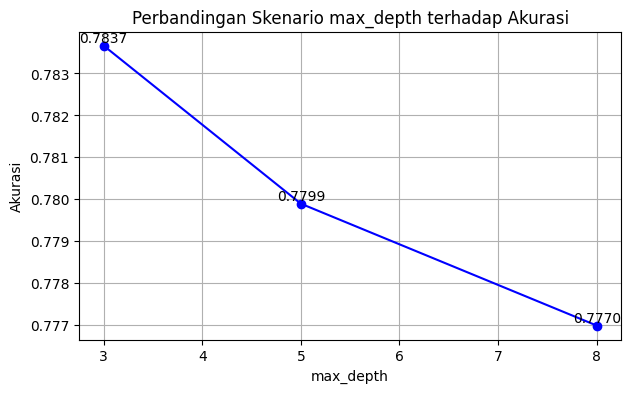


=== HASIL SKENARIO: LEARNING_RATE ===
   Value   Akurasi  mean_test_Precision  mean_test_Recall  mean_test_F1  \
0   0.01  0.787881             0.809787          0.808408      0.808575   
1   0.05  0.779501             0.802785          0.800367      0.801001   
2   0.10  0.773154             0.797852          0.793467      0.795059   

             Skenario  
0  learning_rate=0.01  
1  learning_rate=0.05  
2   learning_rate=0.1  


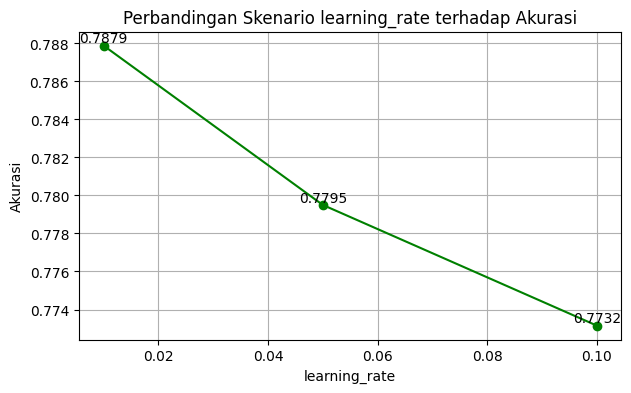


=== HASIL SKENARIO: N_ESTIMATORS ===
   Value   Akurasi  mean_test_Precision  mean_test_Recall  mean_test_F1  \
0    100  0.785577             0.807723          0.806440      0.806548   
1    300  0.779248             0.802718          0.799801      0.800692   
2    500  0.775712             0.799983          0.796002      0.797395   

           Skenario  
0  n_estimators=100  
1  n_estimators=300  
2  n_estimators=500  


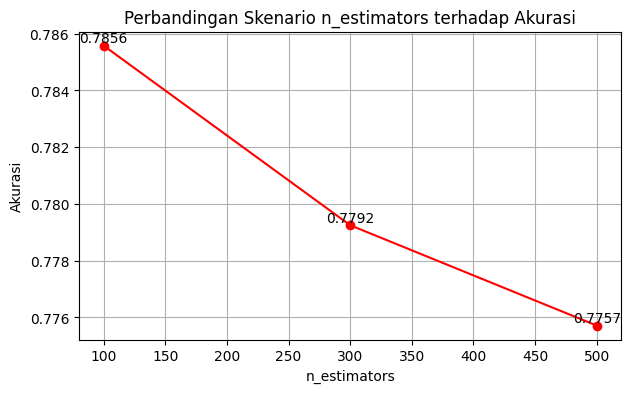


=== HASIL SKENARIO: GAMMA ===
   Value   Akurasi  mean_test_Precision  mean_test_Recall  mean_test_F1  \
0      5  0.790717             0.813024          0.809674      0.810865   
1      1  0.781673             0.804295          0.802955      0.803056   
2      0  0.768147             0.793105          0.789614      0.790714   

  Skenario  
0  gamma=5  
1  gamma=1  
2  gamma=0  


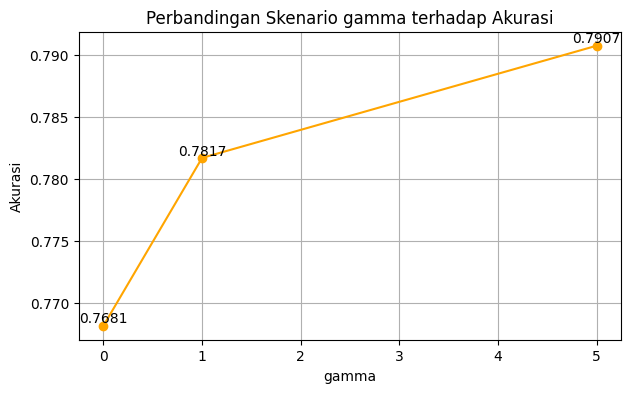


=== HASIL SKENARIO: MIN_CHILD_WEIGHT ===
   Value   Akurasi  mean_test_Precision  mean_test_Recall  mean_test_F1  \
0      5  0.783467             0.806787          0.803005      0.804333   
1      3  0.780787             0.803672          0.801776      0.802189   
2      1  0.776283             0.799965          0.797461      0.798112   

             Skenario  
0  min_child_weight=5  
1  min_child_weight=3  
2  min_child_weight=1  


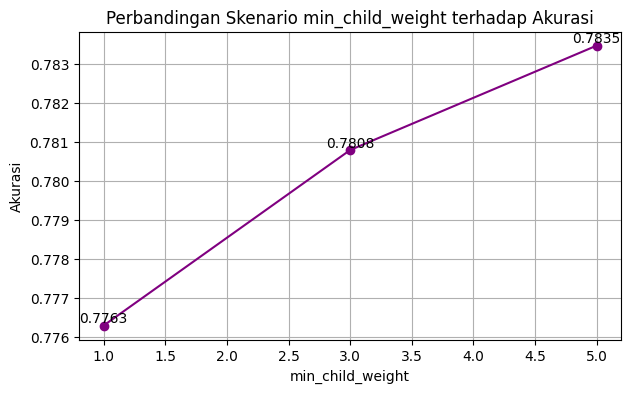


=== HASIL SKENARIO: SAMPLING (TOP 10 TERBAIK) ===
   param_subsample  param_colsample_bytree   Akurasi          Skenario
0              1.0                     0.8  0.782520  sub=1.0, col=0.8
1              1.0                     1.0  0.781094  sub=1.0, col=1.0
2              0.8                     0.8  0.780491  sub=0.8, col=0.8
3              0.6                     0.8  0.779854  sub=0.6, col=0.8
4              0.8                     1.0  0.778894  sub=0.8, col=1.0
5              0.6                     1.0  0.778222  sub=0.6, col=1.0


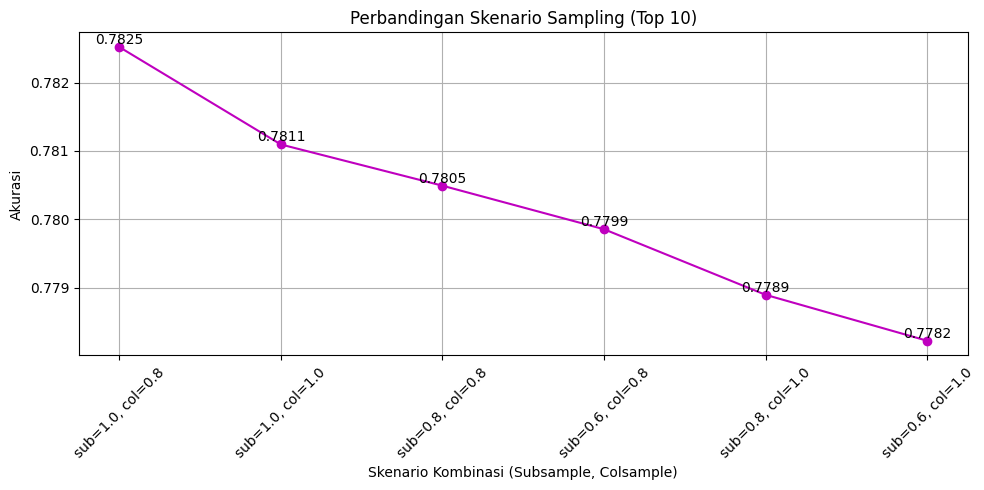

In [57]:
# =====================================================================
# FUNGSI TAMPILAN GABUNGAN (TABEL & GRAFIK)
# =====================================================================
def tampilkan_hasil(df, nama_param, warna='b'):
    
    # 1. Tampilkan Tabel
    print(f"\n=== HASIL SKENARIO: {nama_param.upper()} ===")
    
    df_tampil = (
        df.sort_values(by="Akurasi", ascending=False)
        .reset_index(drop=True)
    )
    
    print(df_tampil)

    # 2. Tampilkan Grafik
    plt.figure(figsize=(7, 4))

    plt.plot(
        df["Value"],
        df["Akurasi"],
        marker='o',
        color=warna
    )

    # Menampilkan nilai akurasi pada titik grafik
    for i in range(len(df)):
        
        txt_murni = f"{df['Akurasi'].iloc[i]:.4f}"[:6]

        plt.text(
            df["Value"].iloc[i],
            df["Akurasi"].iloc[i],
            txt_murni,
            ha='center',
            va='bottom'
        )

    plt.title(f"Perbandingan Skenario {nama_param} terhadap Akurasi")
    plt.xlabel(nama_param)
    plt.ylabel("Akurasi")

    plt.grid(True)
    plt.show()

# =====================================================================
# EKSEKUSI UNTUK TIAP PARAMETER
# =====================================================================
tampilkan_hasil(df_depth, 'max_depth', 'b')

tampilkan_hasil(df_lr, 'learning_rate', 'g')

tampilkan_hasil(df_est, 'n_estimators', 'r')

tampilkan_hasil(df_gamma, 'gamma', 'orange')

tampilkan_hasil(df_min_child, 'min_child_weight', 'purple')

# =====================================================================
# VISUALISASI PARAMETER SAMPLING
# =====================================================================
def tampilkan_sampling():

    global df_sampling_sorted

    df = olah_hasil_grid(None, is_sampling=True)

    df_sampling_sorted = (
        df.sort_values(by="Akurasi", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    print("\n=== HASIL SKENARIO: SAMPLING (TOP 10 TERBAIK) ===")

    print(df_sampling_sorted)

    plt.figure(figsize=(10, 5))

    plt.plot(
        range(len(df_sampling_sorted)),
        df_sampling_sorted["Akurasi"],
        marker='o',
        color='m'
    )

    # Menampilkan nilai akurasi pada grafik
    for i in range(len(df_sampling_sorted)):

        txt_murni = f"{df_sampling_sorted['Akurasi'].iloc[i]:.4f}"[:6]

        plt.text(
            i,
            df_sampling_sorted["Akurasi"].iloc[i],
            txt_murni,
            ha='center',
            va='bottom'
        )

    plt.xticks(
        range(len(df_sampling_sorted)),
        df_sampling_sorted["Skenario"],
        rotation=45
    )

    plt.title("Perbandingan Skenario Sampling (Top 10)")
    plt.xlabel("Skenario Kombinasi (Subsample, Colsample)")
    plt.ylabel("Akurasi")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =====================================================================
# EKSEKUSI SAMPLING
# =====================================================================
tampilkan_sampling()

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# ================================
# DATA
# ================================
X = data[fitur]
y = data["Target"]

# Skenario split
splits = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Menyimpan hasil
hasil = []

# ================================
# LOOP SEMUA SKENARIO
# ================================
for split in splits:
    split_idx = int(split * len(data))
    
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]
    
    # Model
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.01,
        n_estimators=100,
        subsample=0.6,
        colsample_bytree=0.8,
        gamma=0,              
        min_child_weight=1,  
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    
    print("\n==============================")
    print(f"SPLIT {int(split*100)}% : {int((1-split)*100)}%")
    print("==============================")
    print("Akurasi:", round(acc, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
    ))
    
    # Simpan hasil
    hasil.append({
        "Data Latih (%)": int(split*100),
        "Data Uji (%)": int((1-split)*100),
        "Akurasi": round(acc*100, 2)
    })

# ================================
# TABEL HASIL
# ================================
df_hasil = pd.DataFrame(hasil)
print("\n=== RINGKASAN HASIL ===")
print(df_hasil)


SPLIT 90% : 9%
Akurasi: 0.8065

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.81      0.81      0.81        47
    Tidak Memenuhi       0.80      0.80      0.80        46

          accuracy                           0.81        93
         macro avg       0.81      0.81      0.81        93
      weighted avg       0.81      0.81      0.81        93


SPLIT 80% : 19%
Akurasi: 0.7849

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.80      0.80      0.80        98
    Tidak Memenuhi       0.77      0.77      0.77        88

          accuracy                           0.78       186
         macro avg       0.78      0.78      0.78       186
      weighted avg       0.78      0.78      0.78       186


SPLIT 70% : 30%
Akurasi: 0.7814

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.80      0.78    

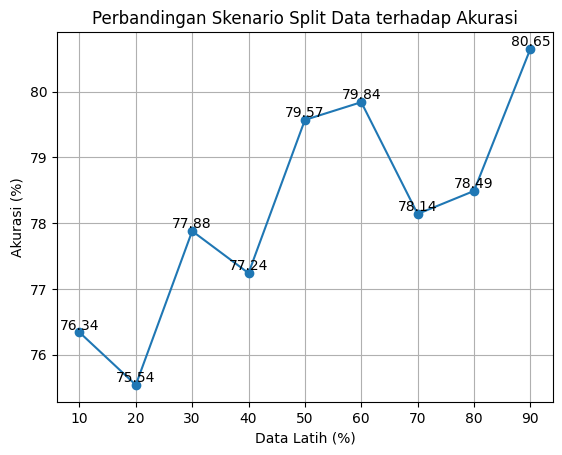

In [46]:
import matplotlib.pyplot as plt

# ================================
# VISUALISASI LINE CHART
# ================================
plt.figure()

# Plot line + marker titik
plt.plot(df_hasil["Data Latih (%)"], df_hasil["Akurasi"], marker='o')

# Tambahkan label di setiap titik
for i, txt in enumerate(df_hasil["Akurasi"]):
    plt.text(
        df_hasil["Data Latih (%)"][i],
        df_hasil["Akurasi"][i],
        str(txt),
        ha='center',
        va='bottom'
    )

# Judul dan label sumbu
plt.title("Perbandingan Skenario Split Data terhadap Akurasi")
plt.xlabel("Data Latih (%)")
plt.ylabel("Akurasi (%)")

# Grid (background kotak-kotak)
plt.grid(True)

# Tampilkan plot
plt.show()

In [ ]:
# =====================================================
# EXPORT HASIL FINAL PENELITIAN (PERBAIKAN GRAFIK KOSONG)
# =====================================================
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import joblib

# Buat folder output
OUTPUT_DIR = "HASIL_PELATIHAN_XGBOOST"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# 1. SIMPAN SELURUH TABEL EXCEL
# =====================================================
data_mentah.head(5).to_excel(f"{OUTPUT_DIR}/01_data_mentah_5_baris.xlsx", index=False)
df_hasil.to_excel(f"{OUTPUT_DIR}/05_split_data.xlsx", index=False)
df_baseline.to_excel(f"{OUTPUT_DIR}/06_baseline.xlsx", index=False)
df_depth.to_excel(f"{OUTPUT_DIR}/07_max_depth.xlsx", index=False)
df_lr.to_excel(f"{OUTPUT_DIR}/08_learning_rate.xlsx", index=False)
df_est.to_excel(f"{OUTPUT_DIR}/09_n_estimators.xlsx", index=False)
df_sampling.to_excel(f"{OUTPUT_DIR}/10_sampling.xlsx", index=False)

# =====================================================
# 2. SIMPAN CLASSIFICATION REPORT
# =====================================================
y_pred_final = model_final.predict(X_test_final)
report = classification_report(y_test_final, y_pred_final, target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"], output_dict=True)
pd.DataFrame(report).transpose().to_excel(f"{OUTPUT_DIR}/02_classification_report.xlsx")

# =====================================================
# 3. GENERASI DAN SIMPAN GRAFIK (DIPECAH PER BARIS AGAR TIDAK KOSONG)
# =====================================================

# --- 11. Split Data ---
plt.figure()
plt.plot(df_hasil["Data Latih (%)"], df_hasil["Akurasi"], marker='o')
for i in range(len(df_hasil)):
    txt_murni = f"{df_hasil['Akurasi'][i]:.4f}"[:4] if isinstance(df_hasil["Akurasi"][i], float) else str(df_hasil["Akurasi"][i])
    plt.text(df_hasil["Data Latih (%)"][i], df_hasil["Akurasi"][i], txt_murni, ha='center', va='bottom')
plt.title("Split Data dan Akurasi")
plt.xlabel("Data Latih (%)")
plt.ylabel("Akurasi (%)")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/11_split_data.png")
plt.close()

# --- 12. Max Depth ---
plt.figure()
plt.plot(df_depth["Value"], df_depth["Akurasi"], marker='o', color='b')
for i in range(len(df_depth)):
    txt_murni = f"{df_depth['Akurasi'].iloc[i]:.4f}"[:4]
    plt.text(df_depth["Value"].iloc[i], df_depth["Akurasi"].iloc[i], txt_murni, ha='center', va='bottom')
plt.title("Max Depth dan Akurasi (Random Search)")
plt.xlabel("Max Depth")
plt.ylabel("Akurasi")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/12_max_depth.png")
plt.close()

# --- 13. Learning Rate ---
plt.figure()
plt.plot(df_lr["Value"], df_lr["Akurasi"], marker='o', color='g')
for i in range(len(df_lr)):
    txt_murni = f"{df_lr['Akurasi'].iloc[i]:.4f}"[:4]
    plt.text(df_lr["Value"].iloc[i], df_lr["Akurasi"].iloc[i], txt_murni, ha='center', va='bottom')
plt.title("Learning Rate dan Akurasi (Random Search)")
plt.xlabel("Learning Rate")
plt.ylabel("Akurasi")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/13_learning_rate.png")
plt.close()

# --- 14. N Estimators ---
plt.figure()
plt.plot(df_est["Value"], df_est["Akurasi"], marker='o', color='r')
for i in range(len(df_est)):
    txt_murni = f"{df_est['Akurasi'].iloc[i]:.4f}"[:4]
    plt.text(df_est["Value"].iloc[i], df_est["Akurasi"].iloc[i], txt_murni, ha='center', va='bottom')
plt.title("n_estimators dan Akurasi (Random Search)")
plt.xlabel("n_estimators")
plt.ylabel("Akurasi")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/14_n_estimators.png")
plt.close()

# --- 15. Sampling (Top 10 Terbaik) ---
plt.figure(figsize=(10,5))
plt.plot(range(len(df_sampling_sorted)), df_sampling_sorted["Akurasi"], marker='o', color='m')
for i in range(len(df_sampling_sorted)):
    txt_murni = f"{df_sampling_sorted['Akurasi'].iloc[i]:.4f}"[:4]
    plt.text(i, df_sampling_sorted["Akurasi"].iloc[i], txt_murni, ha='center', va='bottom')
plt.xticks(range(len(df_sampling_sorted)), df_sampling_sorted["Skenario"], rotation=45)
plt.title("Sampling Top 10 (Random Search)")
plt.xlabel("Skenario")
plt.ylabel("Akurasi")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15_sampling.png")
plt.close()

# --- 03. Confusion Matrix ---
cm = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Memenuhi", "Tidak"])
plt.yticks([0,1], ["Memenuhi", "Tidak"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_confusion_matrix.png")
plt.close()

# --- 04. Feature Importance ---
importances = model_final.feature_importances_
feature_names = np.array(fitur)
idx = np.argsort(importances)
plt.figure(figsize=(7,4))
bars = plt.barh(feature_names[idx], importances[idx])
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.015, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')
plt.xlim(0, max(importances) + 0.08)
plt.xlabel("Importance Score")
plt.title("Feature Importance XGBoost")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_feature_importance.png")
plt.close()

# --- 17. ROC Curve ---
y_prob = model_final.predict_proba(X_test_final)[:, 1]
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/17_roc_curve.png")
plt.close()

# =====================================================
# 4. SAVE MODEL & METADATA
# =====================================================
joblib.dump(model_final, f"{OUTPUT_DIR}/16_model_xgboost.pkl")

# =====================================================
# 5. BUNGKUS KE FILE ZIP
# =====================================================
ZIP_NAME = "HASIL_PELATIHAN_XGBOOST.zip"
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), arcname=file)

print("✅ Semua gambar sekarang tersimpan.")
print(f"📦 File siap diunduh: {ZIP_NAME}")

✅ SELESAI PERBAIKAN! Semua gambar sekarang tersimpan utuh dan bermutu tinggi.
📦 File siap diunduh: HASIL_PELATIHAN_XGBOOST.zip


=== MEMULAI EVALUASI INSTAN: TANPA SMOTE VS DENGAN SMOTE ===
> Menghitung akurasi pada Data Asli (Tanpa SMOTE)...
> Menghitung akurasi pada Data Resampled (Dengan SMOTE)...

=== REKAPITULASI HASIL EVALUASI INSTAN ===


,Metode,Rata-rata Akurasi (CV),Parameter yang Digunakan
0,XGBoost Terbaik (Tanpa SMOTE),0.806452,"depth=3, lr=0.01, est=100, sub=0.6, col=0.8"
1,XGBoost Terbaik (Dengan SMOTE),0.790541,"depth=3, lr=0.01, est=100, sub=0.6, col=0.8"


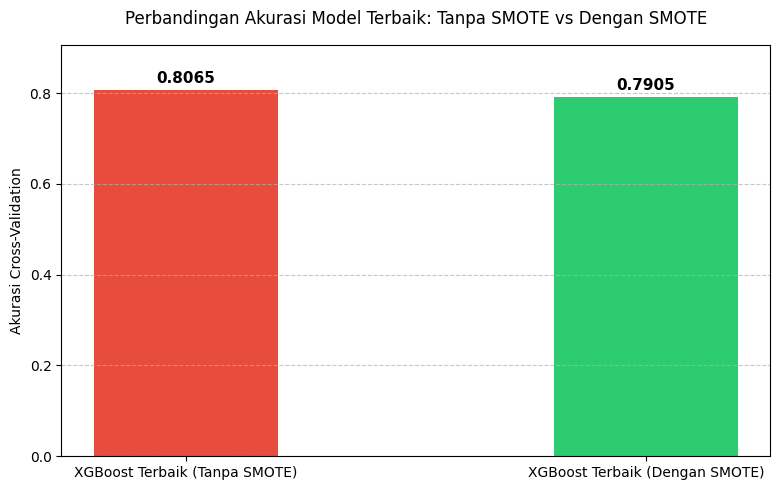

In [60]:
# =====================================================================
# CELL BARU: PERBANDINGAN MODEL TERBAIK (TANPA SMOTE VS DENGAN SMOTE)
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, cross_val_score
from imblearn.over_sampling import SMOTE 

print("=== MEMULAI EVALUASI INSTAN: TANPA SMOTE VS DENGAN SMOTE ===")

# 1. Mengunci kombinasi parameter secara manual ke dalam objek model
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=3,
    learning_rate=0.01,
    n_estimators=100,
    subsample=0.6,
    colsample_bytree=0.8,
    gamma=0,              
    min_child_weight=1,  
    random_state=42
)

kf_comp = KFold(n_splits=3, shuffle=True, random_state=42)

# -----------------------------------------------------------------
# KONDISI A: HITUNG AKURASI TANPA SMOTE
# -----------------------------------------------------------------
print("> Menghitung akurasi pada Data Asli (Tanpa SMOTE)...")
# Perbaikan: Mengubah model_eval_base menjadi model sesuai inisialisasi di atas
skor_tanpa_smote = cross_val_score(model, X_train, y_train, cv=kf_comp, scoring='accuracy').mean()

# -----------------------------------------------------------------
# KONDISI B: HITUNG AKURASI DENGAN SMOTE
# -----------------------------------------------------------------
print("> Menghitung akurasi pada Data Resampled (Dengan SMOTE)...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# Perbaikan: Mengubah model_eval_base menjadi model sesuai inisialisasi di atas
skor_dengan_smote = cross_val_score(model, X_train_smote, y_train_smote, cv=kf_comp, scoring='accuracy').mean()

# -----------------------------------------------------------------
# 2. TAMPILKAN HASILNYA DALAM BENTUK TABEL
# -----------------------------------------------------------------
print("\n=== REKAPITULASI HASIL EVALUASI INSTAN ===")
df_komparasi = pd.DataFrame({
    'Metode': ['XGBoost Terbaik (Tanpa SMOTE)', 'XGBoost Terbaik (Dengan SMOTE)'],
    'Rata-rata Akurasi (CV)': [skor_tanpa_smote, skor_dengan_smote],
    'Parameter yang Digunakan': [
        f"depth={model.max_depth}, lr={model.learning_rate}, est={model.n_estimators}, sub={model.subsample}, col={model.colsample_bytree}",
        f"depth={model.max_depth}, lr={model.learning_rate}, est={model.n_estimators}, sub={model.subsample}, col={model.colsample_bytree}"
    ]
})
display(df_komparasi)

# -----------------------------------------------------------------
# 3. VISUALISASI GRAFIK BATANG DI SCREEN
# -----------------------------------------------------------------
plt.figure(figsize=(8, 5))
kategori = df_komparasi['Metode']
skor_akurasi = df_komparasi['Rata-rata Akurasi (CV)']

# Membuat bar chart
bars = plt.bar(kategori, skor_akurasi, color=['#e74c3c', '#2ecc71'], width=0.4)

# Menambahkan label angka di atas setiap batang grafik
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Perbandingan Akurasi Model Terbaik: Tanpa SMOTE vs Dengan SMOTE", fontsize=12, pad=15)
plt.ylabel("Akurasi Cross-Validation", fontsize=10)
plt.ylim(0, max(skor_akurasi) + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()